# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [2]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [3]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [4]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [5]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [6]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

### Ejercicio 1

In [7]:
Carga el dataframe:

SyntaxError: invalid syntax (1679215432.py, line 1)

In [7]:
df_evaluable = spark.read.parquet("resultados/")

In [ ]:
Muestra el schema completo:

In [8]:
df_evaluable.printSchema()

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)



In [ ]:
Indica cuantas filas contiene:

In [9]:
print(f"El dataframe tiene {df_evaluable.count()} filas")

El dataframe tiene 1909 filas


In [ ]:
¿Cuántos sensores distintos (sensor_id) aparecen?

In [10]:
sensores = df_evaluable.select("sensor_id").distinct().count()
print(f"Aparecen {sensores} sensores distintos")

Aparecen 4 sensores distintos


### Ejercicio 2

In [ ]:
Crea una columna basada en la diferencia o relación entre dos métricas numéricas del DataFrame.

In [11]:
ejercicio2_df = df_evaluable.select(
    (col("avg_temp")/col("avg_humidity")).alias("th")
)
ejercicio2_df.show()

+------------------+
|                th|
+------------------+
| 0.831852516424044|
|0.8876193089391058|
|1.1215187544557643|
|0.9042019166637413|
|0.5575356626007857|
|1.0320392317123006|
|1.1176842342850692|
|1.0491026653293782|
| 1.222850084915856|
|0.7678972630718953|
|0.7559320763204258|
|1.3692793411118738|
|1.1356097560975607|
|1.4100268031189085|
|0.8674119362513113|
|1.3007034696554192|
|0.8576724163702131|
|0.8003221017136818|
|1.0322679308762803|
|0.9551481481481481|
+------------------+
only showing top 20 rows



In [ ]:
¿Cuál es el valor mínimo, máximo y medio de la nueva columna?

In [12]:
medidas_estadisticas = ejercicio2_df.agg(
    min("th").alias("Valor mínimo"),
    max("th").alias("Valor máximo"),
    avg("th").alias("Media")
)

medidas_estadisticas.show()


+-------------------+------------------+------------------+
|       Valor mínimo|      Valor máximo|             Media|
+-------------------+------------------+------------------+
|0.30857690464781984|2.3144869774770602|1.0177867360872528|
+-------------------+------------------+------------------+



### Ejercicio 3

In [ ]:
Aplica un filtro usando varias condiciones a la vez relacionadas con:

humedad,
número de eventos,
sensor.

In [13]:
ejercicio3_df = df_evaluable.filter(
    col("avg_humidity")>50
).filter(
    col("num_events")>5
).filter(
    col("sensor_id")=="S2"
)

ejercicio3_df.show()
                                    

+--------------------+---------+------------------+------------------+------------------+----------+
|              window|sensor_id|         avg_value|          avg_temp|      avg_humidity|num_events|
+--------------------+---------+------------------+------------------+------------------+----------+
|{2026-02-04 20:21...|       S2| 33.13125000000001|          56.61125|          63.77875|         8|
|{2026-02-04 21:18...|       S2|          38.73375| 50.41499999999999|           66.6925|         8|
|{2026-02-04 21:15...|       S2|28.851111111111113| 63.37333333333332| 55.80555555555556|         9|
|{2026-02-04 21:18...|       S2|            40.365| 53.00666666666667| 66.23166666666667|         6|
|{2026-02-04 20:50...|       S2|          31.64875|          45.94625|55.012499999999996|         8|
|{2026-02-04 21:34...|       S2|30.019090909090906| 52.91545454545455| 52.55909090909092|        11|
|{2026-02-04 21:20...|       S2| 36.09714285714286| 66.24571428571429|             52.71|  

In [ ]:
Responde:

¿Cuántos registros cumplen todas las condiciones aplicadas?

In [14]:
print(f"{ejercicio3_df.count()} registros cumplen todas las condiciones aplicadas")

281 registros cumplen todas las condiciones aplicadas


### Ejercicio 4

In [ ]:
Agrupa el DataFrame por sensor_id y obtén estadísticas descriptivas.

In [15]:
ejercicio4_df = df_evaluable.groupBy(df_evaluable.sensor_id)

In [ ]:
¿Qué sensor tiene la mayor media en la variable analizada?

In [16]:
ejercicio4media_df = ejercicio4_df.agg(
    avg("avg_value").alias("Media valor"),
    avg("avg_temp").alias("Media temperatura"),
    avg("avg_humidity").alias("Media humedad"),
    avg("num_events").alias("Media eventos")
)
ejercicio4media_df.show()

+---------+------------------+------------------+------------------+------------------+
|sensor_id|       Media valor| Media temperatura|     Media humedad|     Media eventos|
+---------+------------------+------------------+------------------+------------------+
|       S4|29.898307321609213|54.999486794942776| 55.46147627960205| 7.331236897274633|
|       S3| 29.98551662471003| 55.10942353453675| 55.82948971969097|7.3081761006289305|
|       S2|30.518517205249907|54.800293700185215| 54.89890928015613| 7.515723270440252|
|       S1| 30.21424313210035|   54.901453997943|54.824855157511024| 7.389121338912134|
+---------+------------------+------------------+------------------+------------------+



In [ ]:
He analizado valor, temperatura, humedad y número de eventos.
- En cuanto a valor, el sensor con mayor media es S2
- En cuanto a temperatura, el sensor con mayor media es S3
- En cuanto a humedad, el sensor con mayor media es S3
- En cuanto a número de eventos, el sensor con mayor media es S2

In [ ]:
¿Qué sensor presenta la temperatura máxima?

In [17]:
ejercicio4max_df = df_evaluable.groupBy("sensor_id").max()
ejercicio4max_df.show()



+---------+------------------+-----------------+-----------------+---------------+
|sensor_id|    max(avg_value)|    max(avg_temp)|max(avg_humidity)|max(num_events)|
+---------+------------------+-----------------+-----------------+---------------+
|       S4|45.510000000000005|           80.338|78.42999999999999|             14|
|       S3|            49.445|77.48500000000001|84.34333333333333|             14|
|       S2|47.446666666666665|83.23666666666668|            83.48|             15|
|       S1|            46.425|           77.232|80.59666666666666|             15|
+---------+------------------+-----------------+-----------------+---------------+



In [ ]:
El sensor que presenta la temperatura máxima es el S2

In [ ]:
¿Cuántos grupos o ventanas existen por sensor?

In [18]:
ejercicio4ventanas_df = ejercicio4_df.agg(
    count("window").alias("Ventanas")
)

ejercicio4ventanas_df.show()

+---------+--------+
|sensor_id|Ventanas|
+---------+--------+
|       S4|     477|
|       S3|     477|
|       S2|     477|
|       S1|     478|
+---------+--------+



In [ ]:
Existen 477 ventanas en los sensores S2, S3 y S4, y 478 ventanas en el sensor S1.

### Ejercicio 5

In [ ]:
Usa funciones de ventana para identificar, para cada sensor, el registro con el mayor valor de avg_value.

In [19]:
ordenar_ventana_por_sensor = Window.partitionBy("sensor_id").orderBy(col("avg_value").desc())

ejercicio5_df = df_evaluable.withColumn(
    "ranking", row_number().over(ordenar_ventana_por_sensor)
).filter(    
    col("ranking") == 1
)

ejercicio5_df.show()

+--------------------+---------+------------------+------------------+------------------+----------+-------+
|              window|sensor_id|         avg_value|          avg_temp|      avg_humidity|num_events|ranking|
+--------------------+---------+------------------+------------------+------------------+----------+-------+
|{2026-02-04 18:59...|       S1|            46.425|             48.06|39.855000000000004|         2|      1|
|{2026-02-04 21:38...|       S2|47.446666666666665| 68.57666666666667|             53.46|         3|      1|
|{2026-02-04 17:40...|       S3|            49.445|46.019999999999996|            64.335|         2|      1|
|{2026-02-04 17:38...|       S4|45.510000000000005|            55.015|           62.9375|         4|      1|
+--------------------+---------+------------------+------------------+------------------+----------+-------+



In [ ]:
¿Qué sensor obtiene el valor máximo global entre todos?

In [ ]:
El sensor que obtiene el valor máximo global entre todos atendiendo al avg_value es el S3

### Ejercicio 6

In [ ]:
Crea un DataFrame auxiliar con información adicional sobre sensores (por ejemplo, categoría, ubicación o tipo) y realiza un join.


In [ ]:
Primero, creamos el DataFrame:

In [20]:
ejercicio6_df = spark.sparkContext.parallelize([
    ("S1", "categoría1", "ubicación1", "tipo1"),
    ("S2", "categoría2", "ubicación2", "tipo2"),
    ("S3", "categoría3", "ubicación3", "tipo3"),
    ("S4", "categoría4", "ubicación4", "tipo4")
])

ejercicio6_df = spark.createDataFrame(ejercicio6_df)

ejercicio6_df.printSchema

<bound method DataFrame.printSchema of DataFrame[_1: string, _2: string, _3: string, _4: string]>

In [ ]:
Ahora renombramos las columnas creadas en el nuevo Dataframe por las indicadas en el enunciado:

In [21]:
ejercicio6_df = ejercicio6_df.withColumnRenamed(
    "_1", "sensor_id",
).withColumnRenamed(
    "_2", "categoría",
).withColumnRenamed(
    "_3", "ubicación",
).withColumnRenamed(
    "_4", "tipo"
)

ejercicio6_df.printSchema()

root
 |-- sensor_id: string (nullable = true)
 |-- categoría: string (nullable = true)
 |-- ubicación: string (nullable = true)
 |-- tipo: string (nullable = true)



In [ ]:
Ahora hacemos el join, mostrando los 5 primeros registros del DF ya unido:

In [22]:
joined_df = df_evaluable.join(ejercicio6_df,df_evaluable.sensor_id==ejercicio6_df.sensor_id,"inner")

joined_df.show(5)

+--------------------+---------+------------------+-----------------+-----------------+----------+---------+----------+----------+-----+
|              window|sensor_id|         avg_value|         avg_temp|     avg_humidity|num_events|sensor_id| categoría| ubicación| tipo|
+--------------------+---------+------------------+-----------------+-----------------+----------+---------+----------+----------+-----+
|{2026-02-04 21:07...|       S1|23.845000000000002|           36.995|          66.6975|         4|       S1|categoría1|ubicación1|tipo1|
|{2026-02-04 21:08...|       S1|25.188333333333333|62.65166666666667|            47.37|         6|       S1|categoría1|ubicación1|tipo1|
|{2026-02-04 20:49...|       S1|           34.2825|           63.425|           62.815|         4|       S1|categoría1|ubicación1|tipo1|
|{2026-02-04 21:39...|       S1| 33.40888888888889|64.69777777777779|            51.42|         9|       S1|categoría1|ubicación1|tipo1|
|{2026-02-04 21:09...|       S1|         

### Ejercicio 7

In [ ]:
Extrae la marca de inicio de la ventana y agrúpala por unidades de tiempo truncadas (p. ej., minuto u hora).

In [23]:
ejercicio7_df = df_evaluable.withColumn("tiempo_truncado", date_trunc("minute", col("window.start")))

ejercicio7_df.show(5)

+--------------------+---------+------------------+-----------------+------------------+----------+-------------------+
|              window|sensor_id|         avg_value|         avg_temp|      avg_humidity|num_events|    tiempo_truncado|
+--------------------+---------+------------------+-----------------+------------------+----------+-------------------+
|{2026-02-04 21:33...|       S1|28.516000000000002|57.48599999999999| 69.10600000000001|         5|2026-02-04 21:33:00|
|{2026-02-04 20:21...|       S2| 33.13125000000001|         56.61125|          63.77875|         8|2026-02-04 20:21:00|
|{2026-02-04 20:43...|       S3|31.478888888888896|54.18555555555555| 48.31444444444444|         9|2026-02-04 20:43:00|
|{2026-02-04 20:13...|       S1|            28.744|           51.516|56.974000000000004|         5|2026-02-04 20:13:00|
|{2026-02-04 20:13...|       S2|            29.905|            33.71|           60.4625|         4|2026-02-04 20:13:00|
+--------------------+---------+--------

In [ ]:
¿Cuántas ventanas hay por unidad temporal?

In [24]:
ejercicio7_ventanas_df = ejercicio7_df.groupBy("tiempo_truncado").agg(count("window"))

ejercicio7_ventanas_df.show()

print(f"Hay {ejercicio7_ventanas_df.count()} ventanas")

+-------------------+-------------+
|    tiempo_truncado|count(window)|
+-------------------+-------------+
|2026-02-04 20:54:00|            8|
|2026-02-04 20:51:00|            8|
|2026-02-04 21:08:00|            8|
|2026-02-04 21:28:00|            8|
|2026-02-04 20:02:00|            8|
|2026-02-04 21:29:00|            8|
|2026-02-04 20:14:00|            8|
|2026-02-04 20:49:00|            8|
|2026-02-04 21:04:00|            8|
|2026-02-04 21:11:00|            8|
|2026-02-04 21:35:00|            8|
|2026-02-04 20:22:00|            4|
|2026-02-04 20:48:00|            8|
|2026-02-04 21:17:00|            8|
|2026-02-04 21:05:00|            8|
|2026-02-04 21:31:00|            8|
|2026-02-04 20:21:00|            8|
|2026-02-04 21:15:00|            8|
|2026-02-04 20:56:00|            8|
|2026-02-04 21:36:00|            8|
+-------------------+-------------+
only showing top 20 rows

Hay 241 ventanas


In [ ]:
¿Cuál es la humedad media por cada unidad?

In [25]:
ejercicio7_humedad_df = ejercicio7_df.groupBy("tiempo_truncado").agg(avg("avg_humidity"))

ejercicio7_humedad_df.show()

+-------------------+------------------+
|    tiempo_truncado| avg(avg_humidity)|
+-------------------+------------------+
|2026-02-04 20:54:00| 58.36900622294372|
|2026-02-04 20:51:00|  61.5770386904762|
|2026-02-04 21:08:00|54.277998511904755|
|2026-02-04 21:28:00|  54.3601682449495|
|2026-02-04 20:02:00|  54.9722013888889|
|2026-02-04 21:29:00| 52.59673462301588|
|2026-02-04 20:14:00| 58.96708432539683|
|2026-02-04 20:49:00| 57.08082142857143|
|2026-02-04 21:04:00|  53.9575138888889|
|2026-02-04 21:11:00|  61.1963179563492|
|2026-02-04 21:35:00| 50.24022569444444|
|2026-02-04 20:22:00|55.465626984126985|
|2026-02-04 20:48:00| 56.67911796536797|
|2026-02-04 21:17:00|55.973090999278504|
|2026-02-04 21:05:00|58.198889384920626|
|2026-02-04 21:31:00| 54.97049314574314|
|2026-02-04 20:21:00| 50.66668538059163|
|2026-02-04 21:15:00| 54.47215773809524|
|2026-02-04 20:56:00| 53.72960416666666|
|2026-02-04 21:36:00| 54.97538808760683|
+-------------------+------------------+
only showing top

### Ejercicio 8

In [ ]:
Reparte el DataFrame por sensor_id y añade una columna indicando el identificador de partición. 

In [36]:
ejercicio8_reparticion_df = df_evaluable.repartition(4, "sensor_id")

ejericio8_df = ejercicio8_reparticion_df.withColumn("particion_id", spark_partition_id())

In [ ]:
¿Cuál es la distribución de registros entre las particiciones?

In [39]:
ejericio8_df.groupBy("sensor_id", "particion_id").count().withColumnRenamed("count", "Registros").show()

+---------+------------+---------+
|sensor_id|particion_id|Registros|
+---------+------------+---------+
|       S3|           0|      477|
|       S2|           1|      477|
|       S4|           1|      477|
|       S1|           3|      478|
+---------+------------+---------+



### Ejercicio 9

In [ ]:
Define un criterio personalizado de "anomalía" basado en los valores medios del DataFrame.

In [ ]:
Mi criterio personalizado de anomalía va a ser el siguiente: 
Se considera anómalo cualquier registro donde el avg_value > 45

In [51]:
umbral_anomalia = 45
anomalias_df = df_evaluable.filter(col("avg_value") > umbral_anomalia)

In [ ]:
¿Cuántos registros son anómalos?

In [52]:
total_anomalias = anomalias_df.count()
print(f"Se han detectado {total_anomalias} registros anómalos")

Se han detectado 6 registros anómalos


In [ ]:
¿Qué sensor tiene más anomalías?

In [53]:
ranking_anomalias = anomalias_df.groupBy("sensor_id").count().withColumnRenamed("count", "num_anomalias").orderBy(desc("num_anomalias"))
ranking_anomalias.show()
                                                                                                                      

+---------+-------------+
|sensor_id|num_anomalias|
+---------+-------------+
|       S2|            3|
|       S4|            1|
|       S3|            1|
|       S1|            1|
+---------+-------------+



In [ ]:
El sensor con más anomalías es el S2

### Ejercicio 10

In [ ]:
Crea una puntuación combinando varias columnas del DataFrame (por ejemplo, ponderando avg_value, temperatura y humedad).

In [54]:
avg_value = 50%
avg_temp = 30%
avg_humidity = 20%

Puntuación = (avg_value * 0.5) + (avg_temp * 0.3) + (avg_humidity * 0.2) 

SyntaxError: invalid syntax (1452381.py, line 1)

In [64]:
puntuacion_df = df_evaluable.withColumn("puntuacion", (col("avg_value") * 0.5) + (col("avg_temp") * 0.3) + (col("avg_humidity") * 0.2))

puntuacion_df.show()


+--------------------+---------+------------------+------------------+------------------+----------+------------------+
|              window|sensor_id|         avg_value|          avg_temp|      avg_humidity|num_events|        puntuacion|
+--------------------+---------+------------------+------------------+------------------+----------+------------------+
|{2026-02-04 21:33...|       S1|28.516000000000002| 57.48599999999999| 69.10600000000001|         5|            45.325|
|{2026-02-04 20:21...|       S2| 33.13125000000001|          56.61125|          63.77875|         8|46.304750000000006|
|{2026-02-04 20:43...|       S3|31.478888888888896| 54.18555555555555| 48.31444444444444|         9|            41.658|
|{2026-02-04 20:13...|       S1|            28.744|            51.516|56.974000000000004|         5|           41.2216|
|{2026-02-04 20:13...|       S2|            29.905|             33.71|           60.4625|         4|            37.158|
|{2026-02-04 21:00...|       S1|25.29916

In [ ]:
¿Qué sensor obtiene la puntuación más alta? ¿Cuál es el valor de dicha puntuación?

In [63]:
ganador = puntuacion_df.orderBy(desc("puntuacion")).select("sensor_id", "puntuacion").first()

sensor_top = ganador["sensor_id"]
puntuacion_top = ganador["puntuacion"]

print(f"El sensor con puntuación más alta es {sensor_top} con una puntuación de {puntuacion_top} %")

El sensor con puntuación más alta es S4 con una puntuación de 56.6382 %


### Ejercicio 11

In [ ]:
Crea dos gráficos, convirtiendo el DF de spark a pandas y utiliza la libreria matplotlib
para generar dos gráficos sobre alguna de las variables.

In [66]:
import matplotlib.pyplot as plt
import pandas as pd

In [68]:
pdf = ejercicio7_df.select("sensor_id", "tiempo_truncado", "avg_value", "avg_temp").toPandas()
pdf["tiempo_truncado"] = pd.to_datetime(pdf["tiempo_truncado"])

In [ ]:
Gráfico 1: Histograma

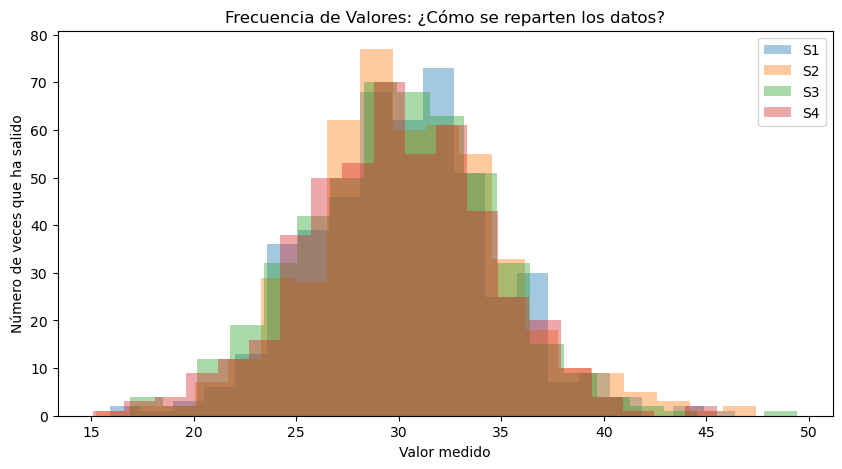

In [80]:
plt.figure(figsize=(10, 5))

for sensor, datos in pdf.groupby("sensor_id"):
    plt.hist(datos["avg_value"], bins=20, alpha=0.4, label=sensor)

plt.title("Frecuencia de Valores: ¿Cómo se reparten los datos?")
plt.xlabel("Valor medido")
plt.ylabel("Número de veces que ha salido")
plt.legend()
plt.show()

In [ ]:
*El punto más alto está alrededor de 30. Los valores más frecuentes están entre el valor 25 y el 35

In [ ]:
Gráfico 2: Gráfico de dispersión

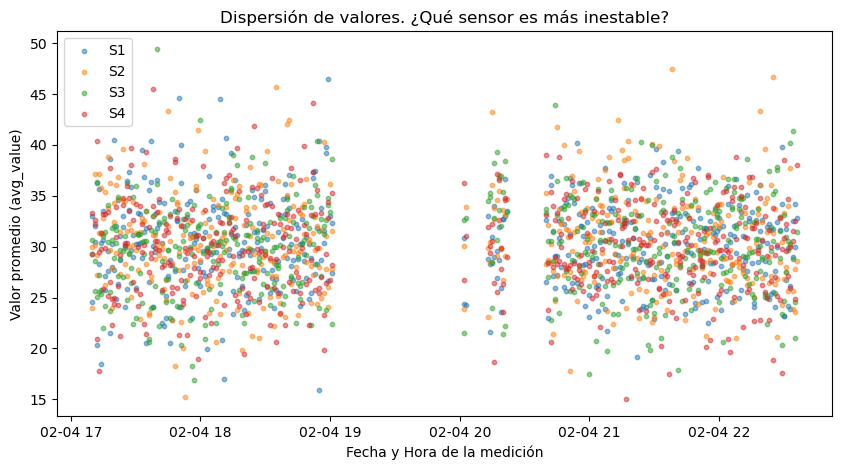

In [78]:
plt.figure(figsize=(10, 5))

for sensor, datos in pdf.groupby("sensor_id"):
    plt.scatter(datos["tiempo_truncado"], datos["avg_value"], label=sensor, alpha=0.5, s=10)

plt.xlabel("Fecha y Hora de la medición") # Eje X
plt.ylabel("Valor promedio (avg_value)")

plt.title("Dispersión de valores. ¿Qué sensor es más inestable?")
plt.legend()
plt.show()

In [ ]:
*La fecha está en formato americano
** De 19:00 a 20:00 hay un gap de datos